<a href="https://colab.research.google.com/github/hye-lily/in-summer/blob/main/%EC%9E%90%EB%8F%99%EC%9E%91%EB%AC%B8%EC%B1%84%EC%A0%90_%EA%B8%B0%EC%B4%88_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 한국어 텍스트 종합 평가 분석기 (kiwipiepy)
**분석 항목:** 어휘 다양성 · 문장 복잡도 · 공기어 연관성 · AWE 스타일 채점

---
> **사용법:** 셀을 순서대로 실행하세요.  
> `[1] 설치` → `[2] .txt 파일 업로드` → `[3] 형태소 분석` → `[4~] 분석`
>
> ⚠️ **모든 비교 지표는 텍스트 길이 차이를 보정한 정규화 값으로 제시됩니다.**

## [1] 환경 설정 및 패키지 설치

In [7]:
!pip install kiwipiepy matplotlib seaborn scipy pandas numpy -q
print('✅ 설치 완료')

✅ 설치 완료


현재 폰트: ['NanumGothic']


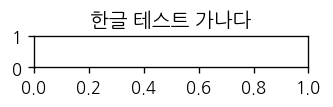

In [34]:
# 한글 폰트 설정 (Colab 전용)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 나눔폰트 설치
os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')

# 캐시 강제 초기화
fm._fmcache = {}

# 설치된 나눔폰트 경로 직접 지정
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 확인
print(f'현재 폰트: {plt.rcParams["font.family"]}')

# 테스트
fig, ax = plt.subplots(figsize=(3,1))
ax.set_title('한글 테스트 가나다')
plt.tight_layout()
plt.show()

In [8]:
import re, math, os
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from kiwipiepy import Kiwi
kiwi = Kiwi()
print('✅ Kiwi 로드 완료')

KIWI_POS_KO = {
    'NNG':'일반명사','NNP':'고유명사','NNB':'의존명사','NP':'대명사','NR':'수사',
    'VV':'동사','VA':'형용사','VX':'보조용언','VCP':'긍정지정사','VCN':'부정지정사',
    'MM':'관형사','MAG':'일반부사','MAJ':'접속부사','IC':'감탄사',
    'JKS':'주격조사','JKO':'목적격조사','JKB':'부사격조사','JX':'보조사','JC':'접속조사',
    'EP':'선어말어미','EF':'종결어미','EC':'연결어미','ETN':'명사형어미','ETM':'관형형어미',
    'XSN':'명사파생접미사','XSV':'동사파생접미사','XSA':'형용사파생접미사','XR':'어근',
    'SF':'마침표','SP':'쉼표','SL':'외국어','SH':'한자','SN':'숫자','UNKNOWN':'미분석'
}
CONTENT_POS = {'NNG','NNP','NNB','NP','VV','VA','MAG','MAJ'}
print('✅ 준비 완료')

✅ Kiwi 로드 완료
✅ 준비 완료


In [9]:
STOP_WORDS = {'황정은', '소라', '나나', '나기', '애자'}

## [2] 텍스트 파일 업로드 (.txt)

아래 셀을 실행하면 파일 선택 버튼이 나타납니다.  
**글 A용 파일**과 **글 B용 파일**을 각각 선택해 업로드하세요.

> - 인코딩: UTF-8 권장 (EUC-KR도 자동 감지)
> - 파일명에 한글이 포함되어도 무방합니다.

In [16]:
from google.colab import files as colab_files

# ── 글 A 업로드 ──
print('📂 글 A 파일을 선택하세요 (.txt)')
uploaded_a = colab_files.upload()
fname_a = list(uploaded_a.keys())[0]

# ── 글 B 업로드 ──
print('\n📂 글 B 파일을 선택하세요 (.txt)')
uploaded_b = colab_files.upload()
fname_b = list(uploaded_b.keys())[0]

# 인코딩 자동 감지 로드
def load_txt(fname, raw_bytes):
    for enc in ['utf-8', 'utf-8-sig', 'euc-kr', 'cp949']:
        try:
            text = raw_bytes.decode(enc).strip()
            print(f'  [{fname}] 인코딩: {enc} | 글자(공백제외): {len(text.replace(" ","").replace(chr(10),""))}자')
            return text
        except:
            continue
    raise ValueError(f'{fname}: 지원되는 인코딩을 찾지 못했습니다.')

TEXT_A = load_txt(fname_a, uploaded_a[fname_a])
TEXT_B = load_txt(fname_b, uploaded_b[fname_b])

# 레이블: 파일명에서 확장자 제거
LABEL_A = os.path.splitext(fname_a)[0]
LABEL_B = os.path.splitext(fname_b)[0]

print(f'\n✅ 로드 완료')
print(f'  글 A → [{LABEL_A}]  어절: {len(TEXT_A.split())}개')
print(f'  글 B → [{LABEL_B}]  어절: {len(TEXT_B.split())}개')
print(f'  길이 비율 (A/B): {len(TEXT_A.split())/max(len(TEXT_B.split()),1):.2f}')

📂 글 A 파일을 선택하세요 (.txt)


Saving 한국어정보학_독후감.txt to 한국어정보학_독후감 (2).txt

📂 글 B 파일을 선택하세요 (.txt)


Saving 한국어정보학_자기소개서.txt to 한국어정보학_자기소개서 (1).txt
  [한국어정보학_독후감 (2).txt] 인코딩: euc-kr | 글자(공백제외): 2086자
  [한국어정보학_자기소개서 (1).txt] 인코딩: euc-kr | 글자(공백제외): 1395자

✅ 로드 완료
  글 A → [한국어정보학_독후감 (2)]  어절: 639개
  글 B → [한국어정보학_자기소개서 (1)]  어절: 427개
  길이 비율 (A/B): 1.50


## [3] Kiwi 형태소 분석 및 전처리

### 📌 주요 Kiwi 품사 태그
| 태그 | 의미 | 태그 | 의미 |
|------|------|------|------|
| NNG | 일반명사 | VV | 동사 |
| NNP | 고유명사 | VA | 형용사 |
| MAG | 일반부사 | MAJ | 접속부사 |
| EC  | 연결어미 | EF  | 종결어미 |

In [17]:
def split_sentences_kiwi(text):
    return [s.text.strip() for s in kiwi.split_into_sents(text) if len(s.text.strip()) > 2]

def analyze_kiwi(text):
    result = kiwi.analyze(text)[0][0]
    return [(t.form, str(t.tag)) for t in result
            if str(t.tag) not in ('SF','SP','SS','SE','SO','SW','SB')]

def content_tokens(pos_tags):
    return [f for f, tag in pos_tags if tag in CONTENT_POS and len(f) >= 2]

data = {}
for label, text in [(LABEL_A, TEXT_A), (LABEL_B, TEXT_B)]:
    print(f'[{label}] Kiwi 분석 중...', end=' ')
    sents    = split_sentences_kiwi(text)
    pos_tags = analyze_kiwi(text)
    ctokens  = content_tokens(pos_tags)
    all_tok  = [f for f, _ in pos_tags]
    data[label] = {
        'raw': text, 'sentences': sents,
        'pos_tags': pos_tags,
        'content_tokens': ctokens,
        'all_tokens': all_tok,
        'n_sents':  len(sents),
        'n_tokens': len(all_tok),
        'n_content': len(ctokens),
        'n_chars':  len(text.replace(' ','').replace('\n','')),
    }
    print(f'완료 | 문장: {len(sents)}개 | 전체토큰: {len(all_tok)}개 | 내용어: {len(ctokens)}개')

# 길이 정보 요약
print('\n=== 텍스트 길이 정보 ===')
df_len = pd.DataFrame({
    '글자 수(공백제외)': [data[l]['n_chars'] for l in [LABEL_A,LABEL_B]],
    '전체 토큰 수':      [data[l]['n_tokens'] for l in [LABEL_A,LABEL_B]],
    '내용어 수':         [data[l]['n_content'] for l in [LABEL_A,LABEL_B]],
    '문장 수':           [data[l]['n_sents'] for l in [LABEL_A,LABEL_B]],
}, index=[LABEL_A,LABEL_B])
print(df_len.to_string())

len_ratio = data[LABEL_A]['n_tokens'] / max(data[LABEL_B]['n_tokens'],1)
print(f'\n⚠️  토큰 수 비율 (A/B): {len_ratio:.2f}  '
      f'→ {"길이 차이 있음 — 정규화 지표 권장" if abs(len_ratio-1)>0.2 else "길이 유사 — 절대값 비교도 가능"}')

[한국어정보학_독후감 (2)] Kiwi 분석 중... 완료 | 문장: 54개 | 전체토큰: 1444개 | 내용어: 428개
[한국어정보학_자기소개서 (1)] Kiwi 분석 중... 완료 | 문장: 43개 | 전체토큰: 935개 | 내용어: 299개

=== 텍스트 길이 정보 ===
                  글자 수(공백제외)  전체 토큰 수  내용어 수  문장 수
한국어정보학_독후감 (2)          2086     1444    428    54
한국어정보학_자기소개서 (1)        1395      935    299    43

⚠️  토큰 수 비율 (A/B): 1.54  → 길이 차이 있음 — 정규화 지표 권장


In [18]:
def content_tokens(pos_tags):
    return [f for f, tag in pos_tags if tag in CONTENT_POS and f not in STOP_WORDS and len(f) >= 2]

print('✅ `content_tokens` 함수에 불용어 필터링 추가 완료')

✅ `content_tokens` 함수에 불용어 필터링 추가 완료


## [4] 어휘 다양성 분석

### 📌 지표 해석 — 정규화 기준
| 지표 | 길이 보정 방법 | 해석 |
|------|--------------|------|
| **TTR** | 없음 (길이에 민감) | 참고용. 텍스트 짧을수록 높아짐 |
| **Root TTR** | √N 정규화 | 길이 편향 부분 보정 |
| **MATTR** | 이동 창(50) 평균 | **길이 독립적. 핵심 지표** |
| **HD-D** | 42 표본 기댓값 | 길이 독립적. 높을수록 다양 |
| **Yule's K** | 반복 패턴 지수 | 길이 독립적. **낮을수록** 다양 |
| **내용어 비율** | 전체 토큰 대비 % | 두 글 직접 비교 가능 |

> ✅ **MATTR·HD-D·Yule's K는 길이에 무관하게 두 글을 직접 비교 가능합니다.**

현재 폰트: ['NanumGothic']


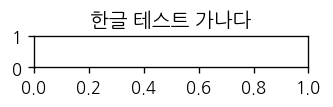

In [35]:
# 한글 폰트 설정 (Colab 전용)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 나눔폰트 설치
os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')

# 캐시 강제 초기화
fm._fmcache = {}

# 설치된 나눔폰트 경로 직접 지정
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 확인
print(f'현재 폰트: {plt.rcParams["font.family"]}')

# 테스트
fig, ax = plt.subplots(figsize=(3,1))
ax.set_title('한글 테스트 가나다')
plt.tight_layout()
plt.show()

In [41]:
def calc_ttr(t):      return len(set(t))/len(t) if t else 0
def calc_root_ttr(t): return len(set(t))/math.sqrt(len(t)) if t else 0

def calc_mattr(tokens, window=50):
    if len(tokens) < window: return calc_ttr(tokens)
    return float(np.mean([len(set(tokens[i:i+window]))/window
                          for i in range(len(tokens)-window+1)]))

def calc_hdd(tokens, sample_size=42):
    if len(tokens) < sample_size: return calc_ttr(tokens)
    freq, N = Counter(tokens), len(tokens)
    total = 0.0
    for count in freq.values():
        try: total += 1.0 - math.comb(N-count,sample_size)/math.comb(N,sample_size)
        except: pass
    return total/sample_size

def calc_yule_k(tokens):
    if not tokens: return 0
    freq=Counter(tokens); N=len(tokens)
    fof=Counter(freq.values())
    return 10000*(sum(v*i**2 for i,v in fof.items())-N)/(N**2)

lex_results = {}
for label in [LABEL_A, LABEL_B]:
    t  = data[label]['content_tokens']
    nt = data[label]['n_tokens']
    lex_results[label] = {
        '① TTR (참고용)':              round(calc_ttr(t),4),
        '② Root TTR (√N 정규화)':      round(calc_root_ttr(t),4),
        '③ MATTR w=50 [길이독립]':     round(calc_mattr(t),4),
        '④ HD-D [길이독립]':           round(calc_hdd(t),4),
        "⑤ Yule's K [길이독립↓good]": round(calc_yule_k(t),2),
        '내용어 수':                    len(t),
        '내용어 비율 (전체토큰 대비%)': round(len(t)/nt*100,2) if nt else 0,
        '유형(Type) 수':               len(set(t)),
        '유형/문장 수 (정규화 Type)':  round(len(set(t))/max(data[label]['n_sents'],1),2),
    }

df_lex = pd.DataFrame(lex_results).T
print('=== 어휘 다양성 지표 ===')
print(df_lex.to_string())

print('\n[해석]')
for metric in ['③ MATTR w=50 [길이독립]','④ HD-D [길이독립]']:
    a,b = lex_results[LABEL_A][metric], lex_results[LABEL_B][metric]
    winner = LABEL_A if a>b else (LABEL_B if b>a else '동일')
    print(f'  {metric}: {LABEL_A}={a:.4f} vs {LABEL_B}={b:.4f}  → 어휘 더 다양: {winner}')
yk = "⑤ Yule's K [길이독립↓good]"
a,b = lex_results[LABEL_A][yk], lex_results[LABEL_B][yk]
winner = LABEL_A if a<b else (LABEL_B if b<a else '동일')
print(f'  {yk}: {LABEL_A}={a:.1f} vs {LABEL_B}={b:.1f}  → 어휘 더 다양: {winner} (낮을수록 좋음)')

=== 어휘 다양성 지표 ===
                  ① TTR (참고용)  ② Root TTR (√N 정규화)  ③ MATTR w=50 [길이독립]  ④ HD-D [길이독립]  ⑤ Yule's K [길이독립↓good]  내용어 수  내용어 비율 (전체토큰 대비%)  유형(Type) 수  유형/문장 수 (정규화 Type)
한국어정보학_독후감 (2)         0.5047              10.4408               0.7471         0.8386                  113.66  428.0              29.64       216.0                4.00
한국어정보학_자기소개서 (1)       0.6421              11.1036               0.7987         0.8956                   63.31  299.0              31.98       192.0                4.47

[해석]
  ③ MATTR w=50 [길이독립]: 한국어정보학_독후감 (2)=0.7471 vs 한국어정보학_자기소개서 (1)=0.7987  → 어휘 더 다양: 한국어정보학_자기소개서 (1)
  ④ HD-D [길이독립]: 한국어정보학_독후감 (2)=0.8386 vs 한국어정보학_자기소개서 (1)=0.8956  → 어휘 더 다양: 한국어정보학_자기소개서 (1)
  ⑤ Yule's K [길이독립↓good]: 한국어정보학_독후감 (2)=113.7 vs 한국어정보학_자기소개서 (1)=63.3  → 어휘 더 다양: 한국어정보학_자기소개서 (1) (낮을수록 좋음)


/tmp/ipykernel_1475/1556340261.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1475/1556340261.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig('/content/01_lexical_diversity.png', bbox_inches='tight', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


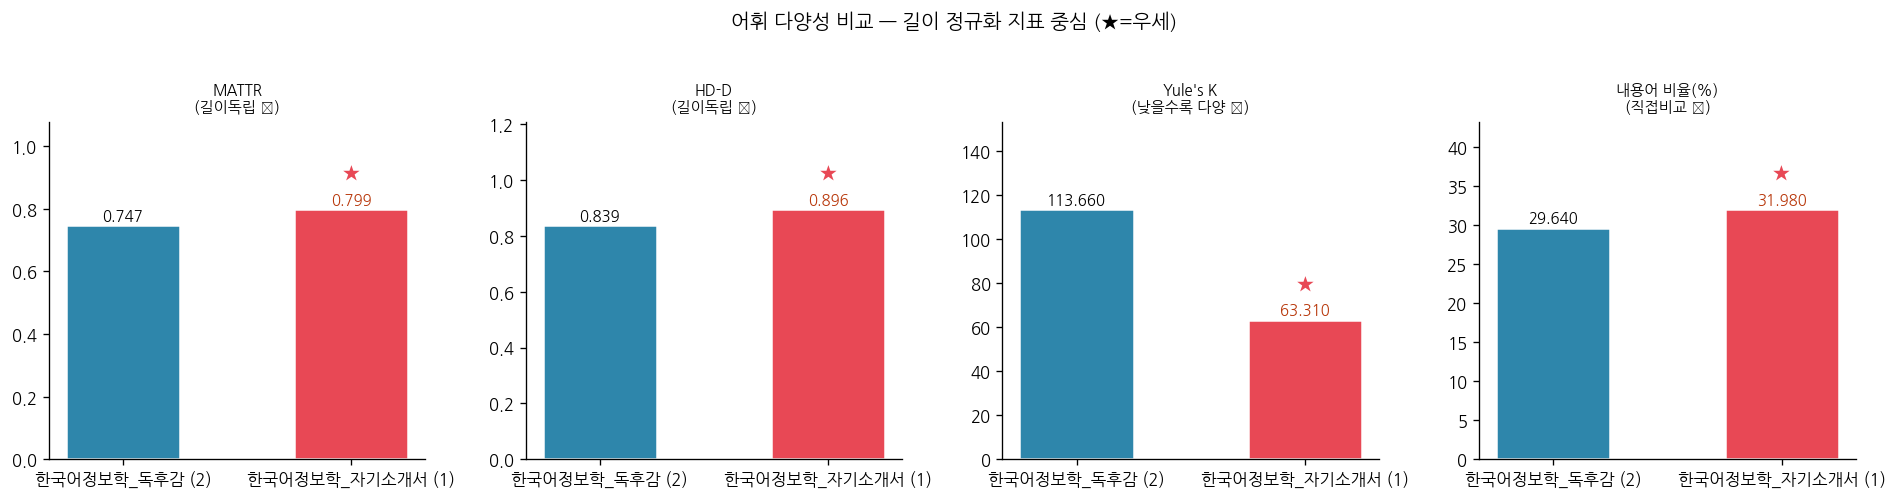

💾 저장: /content/01_lexical_diversity.png


In [42]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#2E86AB','#E84855']
plot_metrics = [
    ('③ MATTR w=50 [길이독립]', 'MATTR\n(길이독립 ✅)', True),
    ('④ HD-D [길이독립]',       'HD-D\n(길이독립 ✅)', True),
    ("⑤ Yule's K [길이독립↓good]", "Yule's K\n(낮을수록 다양 ✅)", False),
    ('내용어 비율 (전체토큰 대비%)', '내용어 비율(%)\n(직접비교 ✅)', True),
]
for ax, (key, title, higher_better) in zip(axes, plot_metrics):
    vals = [lex_results[LABEL_A][key], lex_results[LABEL_B][key]]
    bars = ax.bar([LABEL_A, LABEL_B], vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=6)
    ax.set_ylim(0, max(vals)*1.35 if max(vals)>0 else 1)
    ax.spines[['top','right']].set_visible(False)
    best_idx = np.argmin(vals) if not higher_better else np.argmax(vals)
    for i,(bar,val) in enumerate(zip(bars,vals)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold',
                color='#B8370A' if i==best_idx else 'black')
        if i==best_idx:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.12,
                    '★', ha='center', fontsize=12, color='#E84855')
fig.suptitle('어휘 다양성 비교 — 길이 정규화 지표 중심 (★=우세)', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/01_lexical_diversity.png', bbox_inches='tight', dpi=150)
plt.show(); print('💾 저장: /content/01_lexical_diversity.png')

## [5] 문장 복잡도(통사적 복잡도,Syntax Complexity)분석

### 📌 정규화 기준
| 지표 | 정규화 방법 | 길이 독립성 |
|------|-----------|------------|
| **MLS** (문장당 평균 어절) | 문장 수로 나눔 | ✅ |
| **절 밀도** (EC/문장) | 문장 수로 나눔 | ✅ |
| **EF 종류/문장** | 문장 수로 정규화 | ✅ |
| **MAJ 비율** | 전체 토큰 대비 % | ✅ |
| **품사 비율** | 전체 형태소 대비 % | ✅ |

In [38]:
def analyze_syntax(label):
    sents    = data[label]['sentences']
    pos_tags = data[label]['pos_tags']
    tag_list = [tag for _,tag in pos_tags]
    total_m  = len(tag_list)
    n_sents  = max(len(sents),1)

    sl_eojeol = [len(s.split()) for s in sents]
    sl_char   = [len(s.replace(' ','')) for s in sents]

    # 절 밀도: EC(연결어미) 직접 카운트
    clause_counts = []
    for sent in sents:
        sp = kiwi.analyze(sent)[0][0]
        clause_counts.append(1 + sum(1 for t in sp if str(t.tag)=='EC'))

    # EF, MAJ
    ef_types  = set(f for f,tag in pos_tags if tag=='EF')
    maj_forms = [f for f,tag in pos_tags if tag=='MAJ']
    maj_types = set(maj_forms)

    return {
        'MLS (어절/문장) ✅':             round(float(np.mean(sl_eojeol)),3),
        'MLC (글자/문장) ✅':             round(float(np.mean(sl_char)),3),
        '절 밀도 (EC/문장) ✅':           round(float(np.mean(clause_counts)),3),
        '문장 길이 SD':                    round(float(np.std(sl_eojeol)),3),
        '긴문장비율(≥25어절) ✅':          round(sum(l>=25 for l in sl_eojeol)/n_sents,4),
        '짧은문장비율(≤7어절) ✅':         round(sum(l<=7  for l in sl_eojeol)/n_sents,4),
        'EF 종류/문장 ✅':                 round(len(ef_types)/n_sents,4),
        'MAJ 접속부사 비율(%) ✅':         round(len(maj_forms)/max(total_m,1)*100,4),
        'MAJ 종류 수 ✅':                  len(maj_types),
        'MAJ 목록':                        ', '.join(sorted(maj_types)) if maj_types else '없음',
        '명사 비율(%) ✅':                 round(tag_list.count('NNG')/max(total_m,1)*100,3),
        '동사 비율(%) ✅':                 round(tag_list.count('VV')/max(total_m,1)*100,3),
        '형용사 비율(%) ✅':               round(tag_list.count('VA')/max(total_m,1)*100,3),
        '부사 비율(%) ✅':                 round((tag_list.count('MAG')+tag_list.count('MAJ'))/max(total_m,1)*100,3),
        '총 문장 수':                      len(sents),
        '_sl': sl_eojeol, '_cc': clause_counts,
    }

print('절 밀도 계산 중 (Kiwi EC 태그)...')
syn_results = {l: analyze_syntax(l) for l in [LABEL_A, LABEL_B]}

display_keys = [k for k in syn_results[LABEL_A] if not k.startswith('_')]
df_syn = pd.DataFrame({l:{k:syn_results[l][k] for k in display_keys}
                        for l in [LABEL_A,LABEL_B]}).T
print('\n=== 문장 복잡도 지표 (✅ = 길이 정규화 완료) ===')
print(df_syn.to_string())

절 밀도 계산 중 (Kiwi EC 태그)...

=== 문장 복잡도 지표 (✅ = 길이 정규화 완료) ===
                 MLS (어절/문장) ✅ MLC (글자/문장) ✅ 절 밀도 (EC/문장) ✅ 문장 길이 SD 긴문장비율(≥25어절) ✅ 짧은문장비율(≤7어절) ✅ EF 종류/문장 ✅ MAJ 접속부사 비율(%) ✅ MAJ 종류 수 ✅              MAJ 목록 명사 비율(%) ✅ 동사 비율(%) ✅ 형용사 비율(%) ✅ 부사 비율(%) ✅ 총 문장 수
한국어정보학_독후감 (2)          11.852        38.537          3.019    6.618         0.0741         0.2963     0.1852           0.4848          4  그래서, 그러나, 그러니까, 다만     21.399      6.371       1.177      3.047     54
한국어정보학_자기소개서 (1)         9.977        32.116          2.419     5.16         0.0233         0.3023     0.0465            0.107          1                 그래서     28.128      6.952       0.749      2.781     43


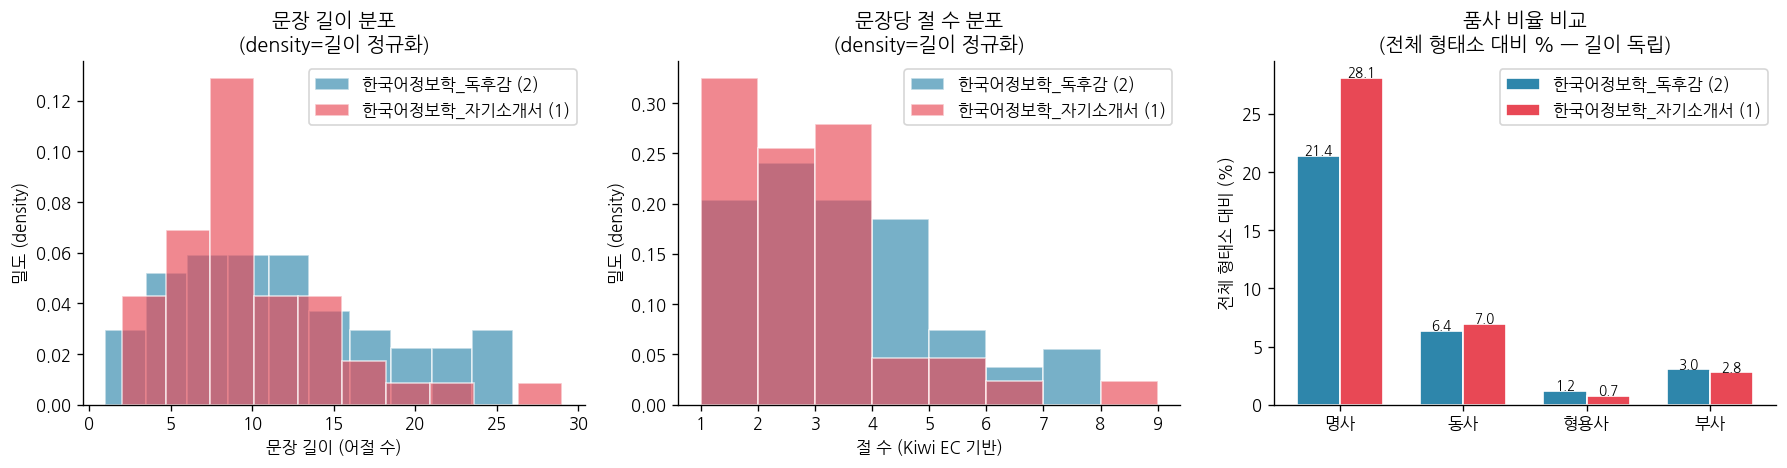

💾 저장: /content/02_syntactic_complexity.png


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2E86AB','#E84855']

# 문장 길이 히스토그램
for label,color in zip([LABEL_A,LABEL_B],colors):
    axes[0].hist(syn_results[label]['_sl'], alpha=0.65, bins=10,
                 label=label, color=color, edgecolor='white', density=True)
axes[0].set_xlabel('문장 길이 (어절 수)')
axes[0].set_ylabel('밀도 (density)')
axes[0].set_title('문장 길이 분포\n(density=길이 정규화)', fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# 절 수 분포
for label,color in zip([LABEL_A,LABEL_B],colors):
    axes[1].hist(syn_results[label]['_cc'], alpha=0.65, bins=range(1,10),
                 label=label, color=color, edgecolor='white', density=True)
axes[1].set_xlabel('절 수 (Kiwi EC 기반)')
axes[1].set_ylabel('밀도 (density)')
axes[1].set_title('문장당 절 수 분포\n(density=길이 정규화)', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

# 품사 비율 비교
pos_m = ['명사 비율(%) ✅','동사 비율(%) ✅','형용사 비율(%) ✅','부사 비율(%) ✅']
xlabels = ['명사','동사','형용사','부사']
x = np.arange(len(pos_m)); w = 0.35
for i,(label,color) in enumerate(zip([LABEL_A,LABEL_B],colors)):
    vals=[syn_results[label][m] for m in pos_m]
    bars=axes[2].bar(x+i*w,vals,w,label=label,color=color,edgecolor='white')
    for bar,val in zip(bars,vals):
        axes[2].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,
                     f'{val:.1f}', ha='center', fontsize=8)
axes[2].set_xticks(x+w/2); axes[2].set_xticklabels(xlabels, fontsize=10)
axes[2].set_ylabel('전체 형태소 대비 (%)')
axes[2].set_title('품사 비율 비교\n(전체 형태소 대비 % — 길이 독립)', fontweight='bold')
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/02_syntactic_complexity.png',bbox_inches='tight',dpi=150)
plt.show(); print('💾 저장: /content/02_syntactic_complexity.png')

## [6] 공기어 연관성 지표 (MI, LogDice, t-score)

### 📌 정규화 기준
| 지표 | 길이 보정 | 해석 |
|------|----------|------|
| **MI** | 기댓값 기반 (N에 의존) | 참고용 |
| **LogDice** | f_x·f_y 기반 정규화 | **길이 독립적. 핵심 지표** |
| **t-score** | 표준화 점수 | 빈도 높은 공기어 탐지 |
| **Top-N 분포** | 상위 N개 비율 | 두 글 직접 비교 가능 |

| 지표      | 주된 질문                     | 해석 초점                 |
| ------- | ------------------------- | --------------------- |
| LogDice | 두 단어가 얼마나 안정적으로 함께 나오는가   | 연어 강도, 결합성            |
| MI      | 기대빈도 대비 얼마나 특이하게 함께 나오는가  | 강한 결합 탐색, 저빈도 과대평가 주의 |
| MI³     | MI에 빈도 가중치를 더함            | MI보다 빈도 안정성 보완        |
| t-score | 함께 나온 빈도가 충분히 안정적인가       | 고빈도 연어에 유리            |
| LLR     | 한 집단에서 다른 집단보다 유의하게 특징적인가 | 집단 간 차이, 키워드성         |


In [25]:
def build_cooc(tokens, window=3):
    cooc=defaultdict(int); freq=Counter(tokens); N=len(tokens)
    for i,w1 in enumerate(tokens):
        for j in range(max(0,i-window),min(len(tokens),i+window+1)):
            if i!=j:
                w2=tokens[j]; pair=(w1,w2) if w1<=w2 else (w2,w1)
                cooc[pair]+=1
    return cooc,freq,N

def calc_assoc(cooc,freq,N,min_freq=2):
    rows=[]
    for (w1,w2),f_xy in cooc.items():
        if f_xy<min_freq: continue
        f_x,f_y=freq[w1],freq[w2]
        if f_x<2 or f_y<2: continue
        E=(f_x*f_y)/N
        if E==0: continue
        rows.append({
            '어휘쌍':  f'{w1} — {w2}', 'f_xy': f_xy,
            'MI':      round(math.log2(f_xy/E),3),
            'MI³':     round(math.log2(f_xy**3/E),3),
            'LogDice': round(14+math.log2(2*f_xy/(f_x+f_y)),3),
            't-score': round((f_xy-E)/math.sqrt(f_xy),3),
        })
    return pd.DataFrame(rows)

assoc_results={}
for label in [LABEL_A,LABEL_B]:
    tokens=data[label]['content_tokens']
    cooc,freq,N=build_cooc(tokens,window=3)
    assoc_results[label]=calc_assoc(cooc,freq,N,min_freq=2)
    print(f'[{label}] 공기어 쌍 수: {len(assoc_results[label])}개')

# 정규화 비교: LogDice 분포 비교
print('\n=== LogDice 분포 비교 (길이 독립 지표) ===')
for label in [LABEL_A,LABEL_B]:
    df=assoc_results[label]
    if df.empty: print(f'  [{label}] 데이터 부족'); continue
    print(f'  [{label}] 평균={df["LogDice"].mean():.3f}  '
          f'중앙값={df["LogDice"].median():.3f}  '
          f'≥5 비율={len(df[df["LogDice"]>=5])/len(df)*100:.1f}%')

for label in [LABEL_A,LABEL_B]:
    print(f'\n--- [{label}] LogDice 상위 10 ---')
    df=assoc_results[label]
    if not df.empty: print(df.sort_values('LogDice',ascending=False).head(10).to_string(index=False))

[한국어정보학_독후감 (2)] 공기어 쌍 수: 345개
[한국어정보학_자기소개서 (1)] 공기어 쌍 수: 179개

=== LogDice 분포 비교 (길이 독립 지표) ===
  [한국어정보학_독후감 (2)] 평균=12.934  중앙값=13.000  ≥5 비율=100.0%
  [한국어정보학_자기소개서 (1)] 평균=13.415  중앙값=13.415  ≥5 비율=100.0%

--- [한국어정보학_독후감 (2)] LogDice 상위 10 ---
     어휘쌍  f_xy    MI    MI³  LogDice  t-score
 너희 — 행복    12 9.741 16.911   16.263    3.460
 다만 — 먼지     4 8.741 12.741   15.000    1.995
 고통 — 껍질     4 8.741 12.741   15.000    1.995
 달리 — 탈주     4 8.741 12.741   15.000    1.995
 소설 — 인물     8 7.420 13.420   14.830    2.812
 세계 — 아기     8 7.934 13.934   14.830    2.817
 사람 — 자신     6 7.741 12.911   14.778    2.438
 부여 — 습득     4 8.157 12.157   14.678    1.993
 먼지 — 행복     4 8.157 12.157   14.678    1.993
당사자 — 대하     4 8.157 12.157   14.678    1.993

--- [한국어정보학_자기소개서 (1)] LogDice 상위 10 ---
     어휘쌍  f_xy    MI    MI³  LogDice  t-score
 교육 — 연구    10 7.639 14.283   15.322    3.146
 구체 — 다양     4 8.224 12.224   15.000    1.993
 기초 — 부족     4 8.224 12.224   15.000    1.993
 다양 — 취미     6 7.8

1. 독후감
공기어 쌍이 총 345개로, 자기소개서보다 훨씬 많음.
LogDice 분포는 평균 12.934, 중앙값 13.000으로 자기소개서보다 약간 낮음
-> 독후감은 자기소개서에 비해 더 넓고 다양한 개념들을 연결함. '행복', '먼지', '고통', '껍질', '탈주', '소설', '인물', '세계', '아기', '자신' 등의 키워드를 통해 추상적이고, 문학적이며, 인간의 내면에 대한 주제를 탐구하는 복잡한 의미망을 형성함. 이는 독후감이 특정 작품을 분석하거나 감상을 표현하는 과정에서 다양한 상황과 감정, 인물에 대한 폭넓은 고찰을 담고 있다는 일반론과 연결됨.

*

 2.자기소개서
  독후감에 비해 공기어 쌍의 수는 적지만, LogDice 값이 약간 더 높다는 것은 응집력 있고 핵심적인 의미 연결에 집중하고 있다는 의미임. 자기소개서는 글쓴이의 학업적 배경, 연구 관심사, 목표, 개인적인 성장 과정을  보여줌. 때문에 자신을 소개하고 특정 분야에 대한 관심과 역량을 어필하기 위해 목표 지향적이고 실용적인 어휘 선택을 함.

/tmp/ipykernel_1475/3104550945.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp=axes[0].boxplot(data_box,labels=[LABEL_A,LABEL_B],patch_artist=True,
/tmp/ipykernel_1475/3104550945.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1475/3104550945.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig('/content/03_association_measures.png',bbox_inches='tight',dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


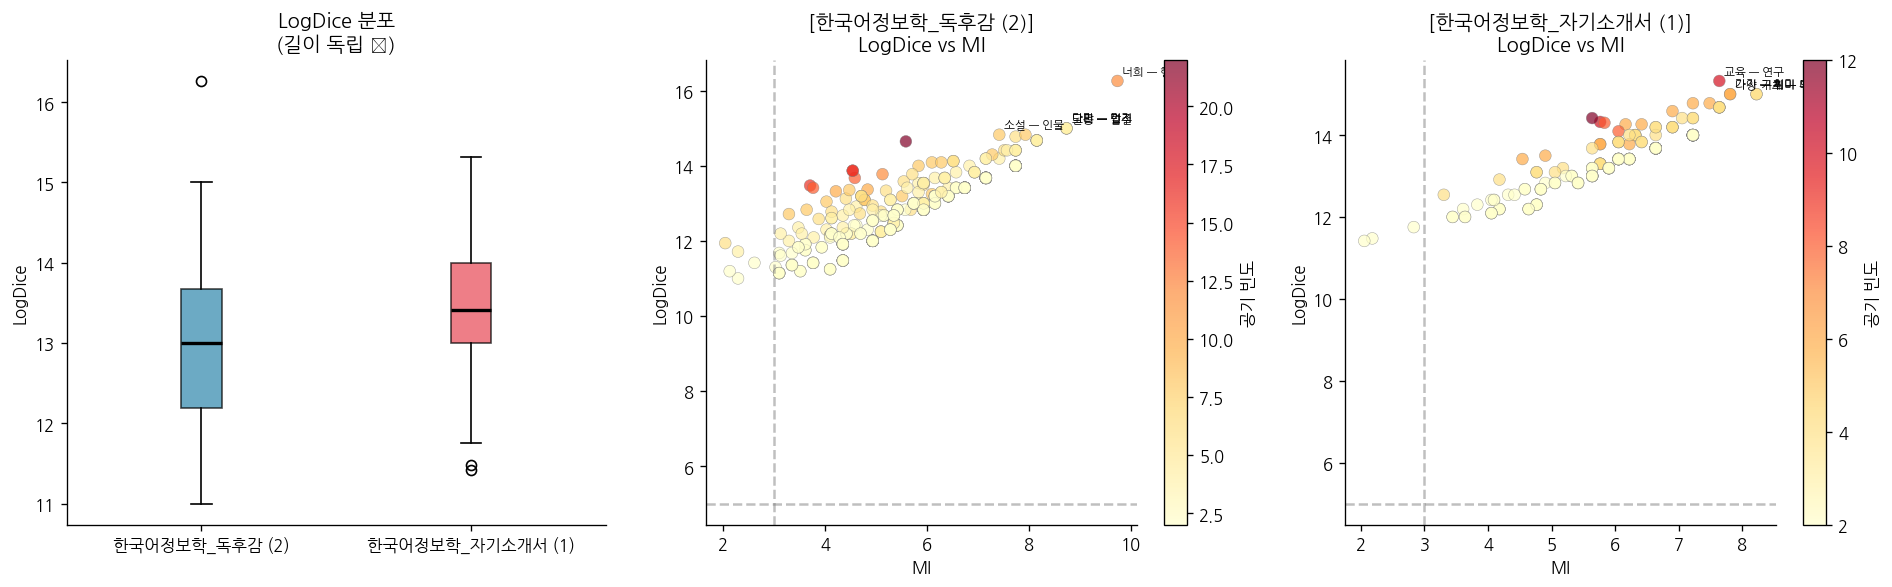

💾 저장: /content/03_association_measures.png


In [40]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
colors=['#2E86AB','#E84855']

# LogDice 분포 비교 (boxplot)
data_box=[assoc_results[l]['LogDice'].dropna().values for l in [LABEL_A,LABEL_B]]
bp=axes[0].boxplot(data_box,labels=[LABEL_A,LABEL_B],patch_artist=True,
                   medianprops={'color':'black','linewidth':2})
for patch,color in zip(bp['boxes'],colors): patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel('LogDice'); axes[0].set_title('LogDice 분포\n(길이 독립 ✅)',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# MI vs LogDice 산점도
for ax,label,color in zip(axes[1:],[LABEL_A,LABEL_B],colors):
    df=assoc_results[label]
    if df.empty: ax.text(0.5,0.5,'데이터 부족',ha='center',va='center',transform=ax.transAxes); continue
    sc=ax.scatter(df['MI'],df['LogDice'],c=df['f_xy'],cmap='YlOrRd',
                  alpha=0.7,edgecolors='grey',linewidth=0.3,s=50)
    plt.colorbar(sc,ax=ax,label='공기 빈도')
    ax.axvline(x=3,color='gray',linestyle='--',alpha=0.5)
    ax.axhline(y=5,color='gray',linestyle='--',alpha=0.5)
    for _,row in df.nlargest(5,'LogDice').iterrows():
        ax.annotate(row['어휘쌍'],(row['MI'],row['LogDice']),
                    fontsize=7,ha='left',va='bottom',xytext=(3,3),textcoords='offset points')
    ax.set_xlabel('MI'); ax.set_ylabel('LogDice')
    ax.set_title(f'[{label}]\nLogDice vs MI',fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/03_association_measures.png',bbox_inches='tight',dpi=150)
plt.show(); print('💾 저장: /content/03_association_measures.png')

 <박스플롯 >
   * 중간값은 유사함:  흔하게 나타나는 어휘 쌍의 결합 강도가 (평균이?) 비슷함

   * 위 아래 선: 일반적 어휘쌍이 결합강도. 길다면, 아주 약하거나 아주 강한 어휘 쌍들까지 폭넓게 존재한다는 뜻이고, 수염이 짧다면 대부분의 어휘 쌍들이 중간 정도의 강도에 집중되어 있다는 뜻임

   * 동그라미-예측을 벗어남(특이한 결합을 가진 어휘쌍)
   -> 독후감은 작품에 대한 감상, 분석을 담기 때문에, 자신의 견해를 강조하기 위해 사용된 인상 깊거나 비유적인 표현, 또는 작품 고유의 핵심어 쌍들이 높은 LogDice 값을 갖도록 만듦.

## [7] AWE 스타일 채점 (내용 / 구조 / 언어)
루브릭

### 📌 정규화 기준
| 영역 | 지표 | 정규화 방법 |
|------|------|------------|
| **내용** | 키워드 밀도, NNG 비율 | 내용어 수 대비 → 길이 독립 ✅ |
| **구조** | MAJ 종류 수/문장, 문단 비율 | 문장 수 대비 → 길이 독립 ✅ |
| **언어** | MATTR, 절/문장, EF 엔트로피 | 모두 비율·평균 기반 ✅ |

In [27]:
CONTENT_KW = {'주장','근거','예시','사례','결과','원인','영향','문제','해결',
              '중요','필요','의미','가치','효과','목적','방법','과정','변화',
              '분석','논의','제안','비교','평가','관점','입장','사실','주제'}
INTRO_M=['이 글에서','본 글은','이번 글은','최근','오늘날','현대','논의하고자','살펴보고자']
CONCL_M=['결론적으로','정리하면','요약하면','이상으로','살펴보았다','알 수 있다','기대한다','바란다']

def ef_entropy(pos_tags):
    ef=[f for f,tag in pos_tags if tag=='EF']
    if len(ef)<2: return 0.0
    freq=Counter(ef); total=sum(freq.values())
    return -sum((c/total)*math.log2(c/total) for c in freq.values())

def score_awe(label):
    raw,pos_tags = data[label]['raw'],data[label]['pos_tags']
    tokens,sents = data[label]['content_tokens'],data[label]['sentences']
    tag_list     = [tag for _,tag in pos_tags]
    total_m,n    = max(len(tag_list),1), max(len(tokens),1)
    n_sents      = max(len(sents),1)

    # 내용 — 모두 비율/밀도 (길이 독립)
    kw_density = sum(1 for t in tokens if t in CONTENT_KW)/n
    noun_ratio = tag_list.count('NNG')/total_m
    c_score = min(10, round((kw_density*150)+(noun_ratio*6)+(min(n/n_sents,15)/15*2),1))

    # 구조 — MAJ 종류/문장 비율 정규화
    para_per_sent = len([p for p in raw.split('\n\n') if len(p.strip())>10])/n_sents
    maj_types     = set(f for f,tag in pos_tags if tag=='MAJ')
    maj_per_sent  = len(maj_types)/n_sents
    s_score = min(10, round(
        (min(para_per_sent,1)*3) + (min(maj_per_sent*10,4)) +
        (2 if any(m in raw for m in INTRO_M) else 0) +
        (2 if any(m in raw for m in CONCL_M) else 0), 1))

    # 언어 — MATTR·절밀도·EF엔트로피 모두 비율 기반
    mattr   = calc_mattr(tokens)
    cc      = float(np.mean([1+sum(1 for t in kiwi.analyze(s)[0][0] if str(t.tag)=='EC')
                              for s in sents]))
    adv_r   = (tag_list.count('MAG')+tag_list.count('MAJ'))/total_m
    ent     = ef_entropy(pos_tags)
    rep_r   = sum(1 for i in range(1,len(tokens)) if tokens[i]==tokens[i-1])/n
    l_score = max(0, min(10, round(
        (mattr*5)+(min(cc,5)/5*2)+(adv_r*5)+(min(ent,2)*0.5)-(rep_r*5),1)))

    scores={'내용 (Content)':c_score,'구조 (Structure)':s_score,'언어 (Language)':l_score}
    scores['총점 (Total)']=round(float(np.mean(list(scores.values()))),2)
    details={
        '내용_키워드밀도(비율)':        round(kw_density,5),
        '내용_명사비율%(NNG)':          round(noun_ratio*100,3),
        '구조_문단수/문장수':           round(para_per_sent,4),
        '구조_MAJ종류수/문장':          round(maj_per_sent,4),
        '구조_MAJ목록':                ', '.join(sorted(maj_types)) if maj_types else '없음',
        '구조_도입표지':               '있음' if any(m in raw for m in INTRO_M) else '없음',
        '구조_마무리표지':             '있음' if any(m in raw for m in CONCL_M) else '없음',
        '언어_MATTR':                  round(mattr,4),
        '언어_절밀도(EC/문장)':        round(cc,3),
        '언어_부사비율%':              round(adv_r*100,3),
        '언어_EF엔트로피':             round(ent,3),
        '언어_반복비율':               round(rep_r,4),
    }
    return scores,details

awe_scores,awe_details={},{}
for label in [LABEL_A,LABEL_B]:
    awe_scores[label],awe_details[label]=score_awe(label)

print('=== AWE 채점 (10점 만점 — 모든 지표 길이 정규화) ===')
print(pd.DataFrame(awe_scores).T.round(2).to_string())
print('\n=== 세부 지표 ===')
print(pd.DataFrame(awe_details).T.to_string())

=== AWE 채점 (10점 만점 — 모든 지표 길이 정규화) ===
                  내용 (Content)  구조 (Structure)  언어 (Language)  총점 (Total)
한국어정보학_독후감 (2)             5.5             0.8            6.0        4.10
한국어정보학_자기소개서 (1)           6.6             2.3            5.3        4.73

=== 세부 지표 ===
                 내용_키워드밀도(비율) 내용_명사비율%(NNG) 구조_문단수/문장수 구조_MAJ종류수/문장            구조_MAJ목록 구조_도입표지 구조_마무리표지 언어_MATTR 언어_절밀도(EC/문장) 언어_부사비율% 언어_EF엔트로피 언어_반복비율
한국어정보학_독후감 (2)        0.02103        21.399     0.0185       0.0741  그래서, 그러나, 그러니까, 다만      없음       없음   0.7471         3.019    3.047     2.184  0.0164
한국어정보학_자기소개서 (1)      0.02676        28.128     0.0233       0.0233                 그래서      있음       없음   0.7987         2.419    2.781     0.535  0.0134


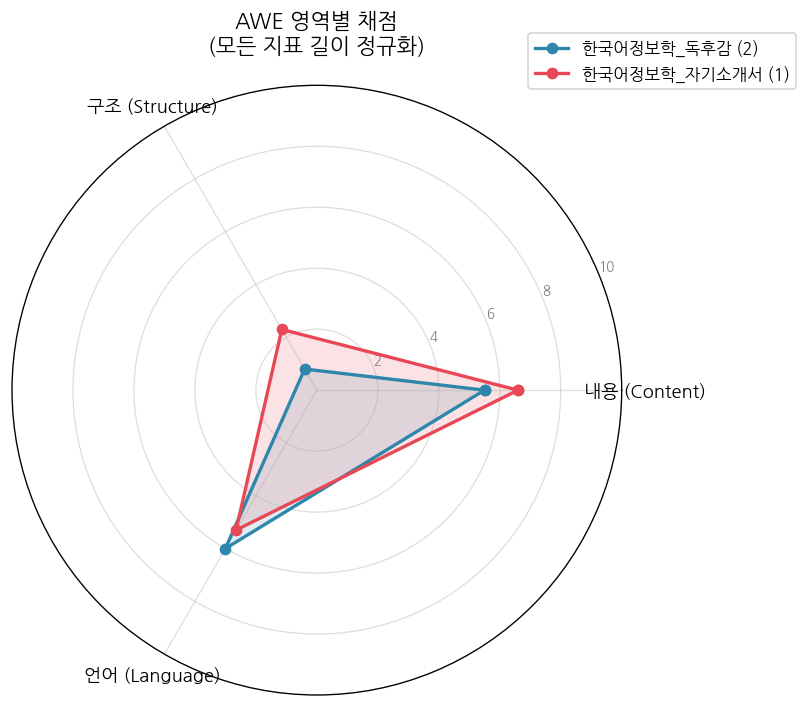

💾 저장: /content/04_awe_radar.png


In [28]:
cats=['내용 (Content)','구조 (Structure)','언어 (Language)']
angles=[n/3*2*3.14159 for n in range(3)]+[0]
fig,ax=plt.subplots(figsize=(7,6),subplot_kw=dict(polar=True))
colors=['#2E86AB','#E84855']
for label,color in zip([LABEL_A,LABEL_B],colors):
    vals=[awe_scores[label][c] for c in cats]+[awe_scores[label][cats[0]]]
    ax.plot(angles,vals,'o-',linewidth=2,label=label,color=color)
    ax.fill(angles,vals,alpha=0.15,color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats,fontsize=11)
ax.set_ylim(0,10); ax.set_yticks([2,4,6,8,10])
ax.set_yticklabels(['2','4','6','8','10'],fontsize=8,color='gray')
ax.set_title('AWE 영역별 채점\n(모든 지표 길이 정규화)',fontsize=13,fontweight='bold',pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.3,1.1))
ax.grid(True,alpha=0.4)
plt.tight_layout()
plt.savefig('/content/04_awe_radar.png',bbox_inches='tight',dpi=150)
plt.show(); print('💾 저장: /content/04_awe_radar.png')

* 자기소개서 (1)는 내용의 키워드 밀도와 명사 비율이 높고, 특히 글의 구조(도입부 명확성, 문단 구성)가 독후감 (2)보다 훨씬 잘 갖춰진 것으로 평가되어 총점에서 우위를 보임.

* 독후감 (2)는 문장의 복잡도(절 밀도)와 종결어미의 다양성 측면에서 자기소개서 (1)보다 우수하여, 언어적인 표현의 풍부함이 더 돋보임.

## [8] 품사 분포 비교 (전체 형태소 대비 % — 길이 독립)

/tmp/ipykernel_1475/3258252924.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1475/3258252924.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig('/content/05_pos_distribution.png',bbox_inches='tight',dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


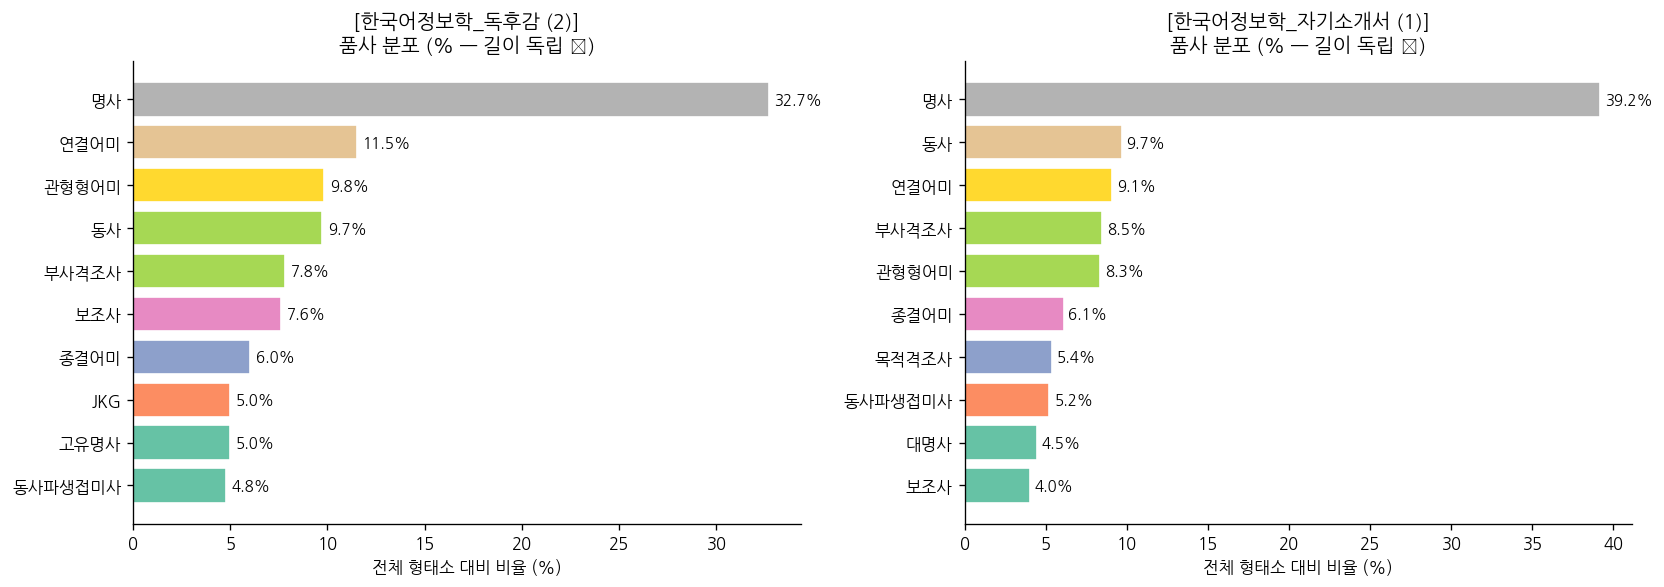

💾 저장: /content/05_pos_distribution.png


In [30]:
POS_GROUP={
    'NNG':'명사','NNP':'고유명사','NNB':'의존명사','NP':'대명사','NR':'수사',
    'VV':'동사','VA':'형용사','VX':'보조용언','VCP':'긍정지정사',
    'MAG':'일반부사','MAJ':'접속부사','MM':'관형사','IC':'감탄사',
    'JKS':'주격조사','JKO':'목적격조사','JKB':'부사격조사','JX':'보조사','JC':'접속조사',
    'EP':'선어말어미','EF':'종결어미','EC':'연결어미','ETN':'명사형어미','ETM':'관형형어미',
    'XSN':'명사파생접미사','XSV':'동사파생접미사','XSA':'형용사파생접미사',
    'SL':'외국어','SH':'한자','SN':'숫자',
}
fig,axes=plt.subplots(1,2,figsize=(14,5))
cmap=plt.cm.Set2([i/10 for i in range(10)])
for ax,label in zip(axes,[LABEL_A,LABEL_B]):
    pos_counter=Counter(POS_GROUP.get(tag,tag) for _,tag in data[label]['pos_tags'])
    top=pos_counter.most_common(10)
    labels_ko=[p for p,_ in top]; vals=[v for _,v in top]
    total=sum(vals); pcts=[v/total*100 for v in vals]  # 비율로 변환
    bars=ax.barh(labels_ko[::-1],pcts[::-1],color=cmap[:len(top)],edgecolor='white')
    for bar,pct in zip(bars,pcts[::-1]):
        ax.text(bar.get_width()+0.3,bar.get_y()+bar.get_height()/2,
                f'{pct:.1f}%',va='center',fontsize=9)
    ax.set_xlabel('전체 형태소 대비 비율 (%)')
    ax.set_title(f'[{label}]\n품사 분포 (% — 길이 독립 ✅)',fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/content/05_pos_distribution.png',bbox_inches='tight',dpi=150)
plt.show(); print('💾 저장: /content/05_pos_distribution.png')

## [9] 종합 비교 리포트 (정규화 지표 중심)

In [31]:
def interp_ttr(v):
    if v>=0.7: return '매우 높음'
    elif v>=0.5: return '높음'
    elif v>=0.35: return '보통'
    else: return '낮음 (반복 많음)'

def interp_mls(v):
    if v>=30: return '매우 긴 문장 (복잡)'
    elif v>=20: return '긴 문장 (학술 수준)'
    elif v>=12: return '보통 (일반 글)'
    else: return '짧은 문장'

def interp_awe(s):
    if s>=8: return '우수'
    elif s>=6: return '양호'
    elif s>=4: return '보통'
    else: return '개선 필요'

print('='*65)
print('    📊 텍스트 종합 평가 리포트 — 정규화 지표 중심')
print('='*65)

for label in [LABEL_A,LABEL_B]:
    d=data[label]; lr=lex_results[label]; sr=syn_results[label]
    print(f'\n▶ [{label}]')
    print(f'  글자: {d["n_chars"]}자 | 전체토큰: {d["n_tokens"]}개 | 문장: {d["n_sents"]}개')
    print(f'  내용어 비율: {lr["내용어 비율 (전체토큰 대비%)"]:.1f}%')
    print(f'\n  [어휘 다양성 — 길이독립 지표]')
    print(f'    MATTR  : {lr["③ MATTR w=50 [길이독립]"]:.4f}  ({interp_ttr(lr["③ MATTR w=50 [길이독립]"])})')
    print(f'    HD-D   : {lr["④ HD-D [길이독립]"]:.4f}')
    yk="⑤ Yule's K [길이독립↓good]"
    print(f'    Yule K : {lr[yk]:.1f}  (낮을수록 다양)')
    print(f'    Type/문장: {lr["유형/문장 수 (정규화 Type)"]:.2f}  (정규화 유형 수)')
    print(f'\n  [문장 복잡도 — 정규화 지표]')
    print(f'    MLS    : {sr["MLS (어절/문장) ✅"]:.1f}어절/문장  ({interp_mls(sr["MLS (어절/문장) ✅"])})')
    print(f'    절 밀도: {sr["절 밀도 (EC/문장) ✅"]:.3f}절/문장')
    print(f'    EF종류/문장: {sr["EF 종류/문장 ✅"]:.4f}')
    print(f'    MAJ 비율%: {sr["MAJ 접속부사 비율(%) ✅"]:.3f}%  | 종류: {sr["MAJ 목록"]}')
    a=awe_scores[label]
    print(f'\n  [AWE 채점 — 길이 정규화 완료]')
    for dom in ['내용 (Content)','구조 (Structure)','언어 (Language)']:
        print(f'    {dom}: {a[dom]:.1f}/10  ({interp_awe(a[dom])})')
    print(f'    총점: {a["총점 (Total)"]:.2f}/10  ({interp_awe(a["총점 (Total)"])})')

# 비교 요약
norm_pairs=[
    ('어휘 MATTR [길이독립]', '③ MATTR w=50 [길이독립]', lex_results, True),
    ('어휘 HD-D [길이독립]',  '④ HD-D [길이독립]',       lex_results, True),
    ("Yule's K [길이독립]",  "⑤ Yule's K [길이독립↓good]", lex_results, False),
    ('MLS (어절/문장)',       'MLS (어절/문장) ✅',       syn_results, True),
    ('절 밀도 (EC/문장)',     '절 밀도 (EC/문장) ✅',    syn_results, True),
    ('MAJ 비율%',             'MAJ 접속부사 비율(%) ✅',  syn_results, True),
    ('AWE 총점',              '총점 (Total)',             awe_scores,  True),
]
print('\n'+'='*65)
print('  📌 두 글 정규화 지표 비교 요약')
print('='*65)
print(f'  {'지표':<25} {LABEL_A:<12} {LABEL_B:<12} 우세')
print('  '+'-'*55)
for name,key,src,higher in norm_pairs:
    a=src[LABEL_A][key]; b=src[LABEL_B][key]
    winner=LABEL_A if (a>b)==higher else (LABEL_B if (b>a)==higher else '동일')
    if a==b: winner='동일'
    print(f'  {name:<25} {str(round(a,3)):<12} {str(round(b,3)):<12} {winner}')
print('\n✅ 분석 완료. 그래프: /content/ 폴더 저장')

    📊 텍스트 종합 평가 리포트 — 정규화 지표 중심

▶ [한국어정보학_독후감 (2)]
  글자: 2086자 | 전체토큰: 1444개 | 문장: 54개
  내용어 비율: 29.6%

  [어휘 다양성 — 길이독립 지표]
    MATTR  : 0.7471  (매우 높음)
    HD-D   : 0.8386
    Yule K : 113.7  (낮을수록 다양)
    Type/문장: 4.00  (정규화 유형 수)

  [문장 복잡도 — 정규화 지표]
    MLS    : 11.9어절/문장  (짧은 문장)
    절 밀도: 3.019절/문장
    EF종류/문장: 0.1852
    MAJ 비율%: 0.485%  | 종류: 그래서, 그러나, 그러니까, 다만

  [AWE 채점 — 길이 정규화 완료]
    내용 (Content): 5.5/10  (보통)
    구조 (Structure): 0.8/10  (개선 필요)
    언어 (Language): 6.0/10  (양호)
    총점: 4.10/10  (보통)

▶ [한국어정보학_자기소개서 (1)]
  글자: 1395자 | 전체토큰: 935개 | 문장: 43개
  내용어 비율: 32.0%

  [어휘 다양성 — 길이독립 지표]
    MATTR  : 0.7987  (매우 높음)
    HD-D   : 0.8956
    Yule K : 63.3  (낮을수록 다양)
    Type/문장: 4.47  (정규화 유형 수)

  [문장 복잡도 — 정규화 지표]
    MLS    : 10.0어절/문장  (짧은 문장)
    절 밀도: 2.419절/문장
    EF종류/문장: 0.0465
    MAJ 비율%: 0.107%  | 종류: 그래서

  [AWE 채점 — 길이 정규화 완료]
    내용 (Content): 6.6/10  (양호)
    구조 (Structure): 2.3/10  (개선 필요)
    언어 (Language): 5.3/10  (보통)
    총점: 4.73/10  (보통)

  📌 두 글 

## [10] 종합 대시보드

/tmp/ipykernel_1475/4118016946.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig('/content/00_dashboard.png',bbox_inches='tight',dpi=150,facecolor='#F8F9FA')
/tmp/ipykernel_1475/4118016946.py:73: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) NanumGothic.
  plt.savefig('/content/00_dashboard.png',bbox_inches='tight',dpi=150,facecolor='#F8F9FA')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


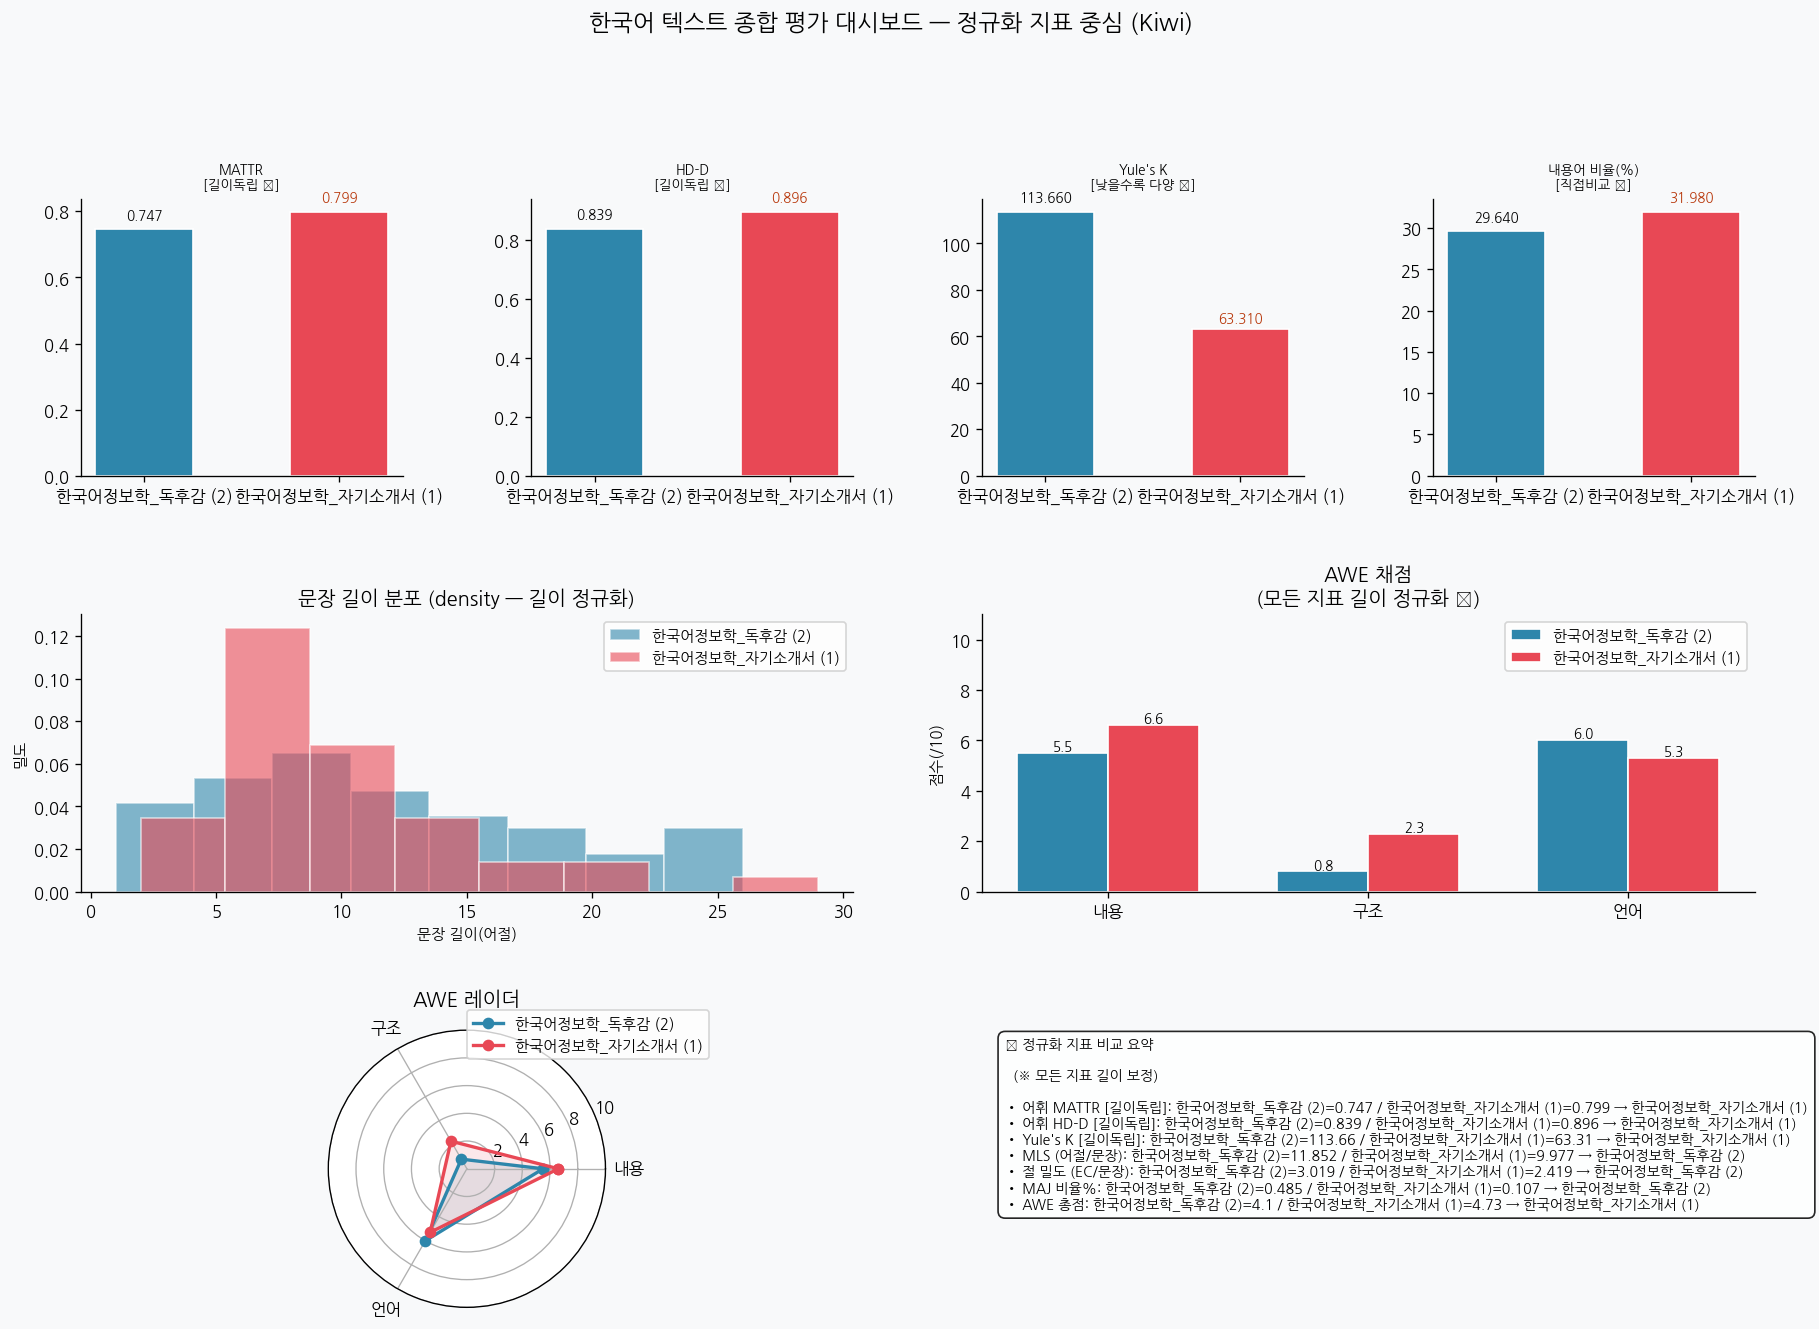

💾 저장: /content/00_dashboard.png


In [32]:
fig=plt.figure(figsize=(18,12))
fig.patch.set_facecolor('#F8F9FA')
gs=fig.add_gridspec(3,4,hspace=0.5,wspace=0.4)
colors=['#2E86AB','#E84855']

# 1행: 길이독립 어휘 지표 4개
dash_metrics=[
    ('③ MATTR w=50 [길이독립]','MATTR\n[길이독립 ✅]',True),
    ('④ HD-D [길이독립]','HD-D\n[길이독립 ✅]',True),
    ("⑤ Yule's K [길이독립↓good]","Yule's K\n[낮을수록 다양 ✅]",False),
    ('내용어 비율 (전체토큰 대비%)','내용어 비율(%)\n[직접비교 ✅]',True),
]
for col,(key,title,hb) in enumerate(dash_metrics):
    ax=fig.add_subplot(gs[0,col])
    vals=[lex_results[LABEL_A][key],lex_results[LABEL_B][key]]
    bars=ax.bar([LABEL_A,LABEL_B],vals,color=colors,width=0.5,edgecolor='white')
    ax.set_title(title,fontsize=8,fontweight='bold')
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor('#F8F9FA')
    best=np.argmin(vals) if not hb else np.argmax(vals)
    for i,(bar,val) in enumerate(zip(bars,vals)):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.04,
                f'{val:.3f}',ha='center',fontsize=8,fontweight='bold',
                color='#B8370A' if i==best else 'black')

# 2행 왼쪽: 문장 길이 분포 (density)
ax=fig.add_subplot(gs[1,:2])
for label,color in zip([LABEL_A,LABEL_B],colors):
    ax.hist(syn_results[label]['_sl'],alpha=0.6,bins=8,label=label,
            color=color,edgecolor='white',density=True)
ax.set_xlabel('문장 길이(어절)',fontsize=9); ax.set_ylabel('밀도',fontsize=9)
ax.set_title('문장 길이 분포 (density — 길이 정규화)',fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False); ax.set_facecolor('#F8F9FA')

# 2행 오른쪽: AWE 바 차트
ax=fig.add_subplot(gs[1,2:])
awe_d=['내용 (Content)','구조 (Structure)','언어 (Language)']
x=np.arange(len(awe_d)); w=0.35
for i,(label,color) in enumerate(zip([LABEL_A,LABEL_B],colors)):
    vals=[awe_scores[label][d] for d in awe_d]
    bars=ax.bar(x+i*w,vals,w,label=label,color=color,edgecolor='white')
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.1,
                f'{val:.1f}',ha='center',fontsize=8)
ax.set_xticks(x+w/2); ax.set_xticklabels(['내용','구조','언어'],fontsize=10)
ax.set_ylim(0,11); ax.set_ylabel('점수(/10)',fontsize=9)
ax.set_title('AWE 채점\n(모든 지표 길이 정규화 ✅)',fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False); ax.set_facecolor('#F8F9FA')

# 3행 왼쪽: 레이더
ax_r=fig.add_subplot(gs[2,:2],polar=True)
cats=['내용 (Content)','구조 (Structure)','언어 (Language)']
angles_=[n/3*2*3.14159 for n in range(3)]+[0]
for label,color in zip([LABEL_A,LABEL_B],colors):
    vals=[awe_scores[label][c] for c in cats]+[awe_scores[label][cats[0]]]
    ax_r.plot(angles_,vals,'o-',linewidth=2,label=label,color=color)
    ax_r.fill(angles_,vals,alpha=0.12,color=color)
ax_r.set_xticks(angles_[:-1]); ax_r.set_xticklabels(['내용','구조','언어'],fontsize=10)
ax_r.set_ylim(0,10); ax_r.set_title('AWE 레이더',fontweight='bold',pad=15)
ax_r.legend(loc='upper right',bbox_to_anchor=(1.4,1.1),fontsize=9)

# 3행 오른쪽: 정규화 비교 요약
ax_t=fig.add_subplot(gs[2,2:]); ax_t.axis('off'); ax_t.set_facecolor('#F8F9FA')
sum_lines=['📌 정규화 지표 비교 요약', '', f'  (※ 모든 지표 길이 보정)', '']
for name,key,src,hb in norm_pairs:
    a=src[LABEL_A][key]; b=src[LABEL_B][key]
    winner=LABEL_A if (a>b)==hb and a!=b else (LABEL_B if (b>a)==hb and a!=b else '동일')
    sum_lines.append(f'• {name}: {LABEL_A}={round(a,3)} / {LABEL_B}={round(b,3)} → {winner}')
ax_t.text(0.03,0.97,'\n'.join(sum_lines),transform=ax_t.transAxes,fontsize=8.5,
          va='top',ha='left',bbox=dict(boxstyle='round,pad=0.5',facecolor='white',alpha=0.85))

fig.suptitle('한국어 텍스트 종합 평가 대시보드 — 정규화 지표 중심 (Kiwi)',
             fontsize=14,fontweight='bold',y=1.01)
plt.savefig('/content/00_dashboard.png',bbox_inches='tight',dpi=150,facecolor='#F8F9FA')
plt.show(); print('💾 저장: /content/00_dashboard.png')